In [1]:
import xarray as xr
import ndsl.dsl.gt4py_utils as gt_utils
from ndsl import GridSizer, Quantity, QuantityFactory, TileCommunicator, TilePartitioner, LocalComm, SubtileGridSizer
import ndsl.constants as constants
from ndsl.grid import (
    AngleGridData,
    ContravariantGridData,
    GridData,
    HorizontalGridData,
    MetricTerms,
    VerticalGridData,
)

import numpy as np
import matplotlib.pyplot as plt
import datetime

2026-02-17 21:38:18|INFO|rank 0|ndsl.logging:Constant selected: ConstantVersions.UFS


In [2]:
nx_tile=20
ny_tile=20
nz=79
n_halo=3
date = datetime.datetime(2020, 1, 1, 12, tzinfo=datetime.timezone.utc)
backend = "numpy"

In [3]:
rank = 0
buffd = {}
comm = LocalComm(rank, 1, buffer_dict=buffd)
communicator = TileCommunicator.from_layout(comm=comm, layout=(1,1))

sizer = SubtileGridSizer.from_tile_params(
    nx_tile=nx_tile,
    ny_tile=ny_tile,
    nz=nz,
    n_halo=n_halo,
    layout=(1,1),
    tile_partitioner=communicator.partitioner.tile,
    tile_rank=communicator.tile.rank,
    backend=backend
)
quantity_factory = QuantityFactory(
    sizer, backend=backend
)

metric_terms = MetricTerms(
    quantity_factory=quantity_factory,
    communicator=communicator,
    grid_type=4,
    eta_file="eta79.nc",
)
horizontal_data = HorizontalGridData.new_from_metric_terms(metric_terms)
vertical_data = VerticalGridData.new_from_metric_terms(metric_terms)
contravariant_data = ContravariantGridData.new_from_metric_terms(metric_terms)
angle_data = AngleGridData.new_from_metric_terms(metric_terms)
grid_data = GridData(
    horizontal_data=horizontal_data,
    vertical_data=vertical_data,
    contravariant_data=contravariant_data,
    angle_data=angle_data,
)

In [4]:
import pyfv3.initialization.test_cases.initialize_aquaplanet as aq

In [5]:
state = aq.init_aquaplanet_state(
    grid_data=grid_data,
    quantity_factory=quantity_factory,
    hydrostatic=False,
    comm=comm,
)

3 24 3 24
20 20 80
(27, 27)
(24, 81)
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:0, 200.0, 308956.91185718955, 44098.03442591196, 300.0
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:1, 200.0, 281395.66329888214, 27561.248558307416, 646.7159
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:2, 200.00000000000023, 261848.6741096665, 19546.989189215645, 1045.222
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:3, 200.00000000000017, 247151.67196655957, 14697.002143106918, 1469.188
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:4, 200.00000000000003, 235487.3943303705, 11664.277636189072, 1897.829
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:5, 200.00000000000023, 225767.1600259179, 9720.234304452606, 2325.385
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:6, 200.0, 217314.78353188868, 8452.376494029217, 2754.396
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:7, 200.0, 209630.82247519473, 7683.961056693952, 3191.294
2026-02-17 21:38:19|INFO|rank 0|ndsl.logging:8, 200.0000000000002, 202432.7291792973, 719

/pyfv3/pyfv3/initialization/init_utils.py:505: RuntimeWarning: invalid value encountered in scalar divide
  pt[i, j, k] = (gz[i, k] - gz[i, k+1]) / (constants.RDGAS * (


In [6]:
print(state.pt.field[:, :, -2])

[[299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078]
 [299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078]
 [299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078]
 [299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.50309078
  299.50309078 299.50309078 299.50309078 299.50309078 299.5

In [7]:
import matplotlib.pyplot as plt

(27, 27, 80)


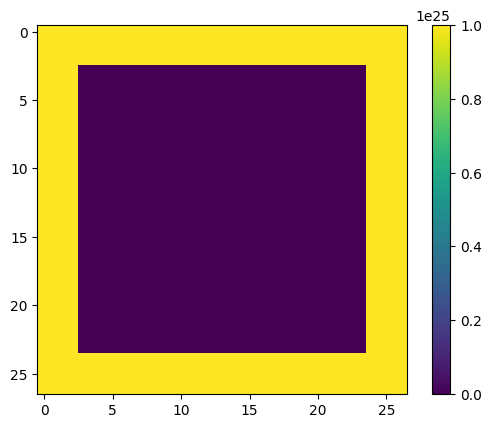

In [12]:
print(state.delp.data.shape)
plt.imshow(state.delz.data[:, :, -2])
plt.colorbar()

In [9]:
print(grid_data.lat.shape)

(27, 27)
